# Import Libraries

In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Loading Dataset

In [30]:
order_items = pd.read_csv(r"C:\Users\urvas\Downloads\Customer segmentation\data\olist_order_items_dataset.csv")
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


# Data Cleaning and Preprocessing

In [31]:
order_items.shape

(112650, 7)

In [32]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [33]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [34]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## Items per Order (Customer Buying Behavior)

In [35]:
items_per_order = order_items.groupby('order_id').size()

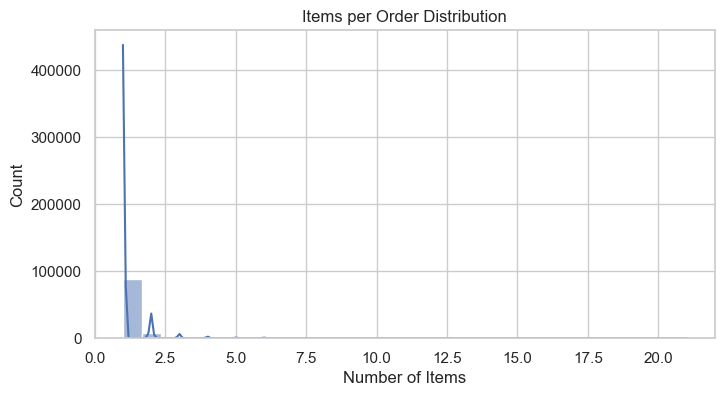

In [49]:
plt.figure(figsize=(8,4))
sns.histplot(items_per_order, bins=30, kde=True)
plt.title("Items per Order Distribution")
plt.xlabel("Number of Items")
plt.show()

## Price Distribution

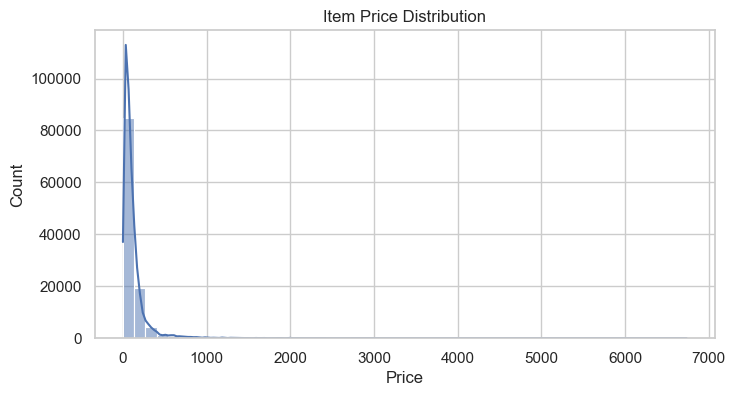

In [48]:
plt.figure(figsize=(8,4))
sns.histplot(order_items['price'], bins=50, kde=True)
plt.title("Item Price Distribution")
plt.xlabel("Price")
plt.show()

## Freight Value Analysis

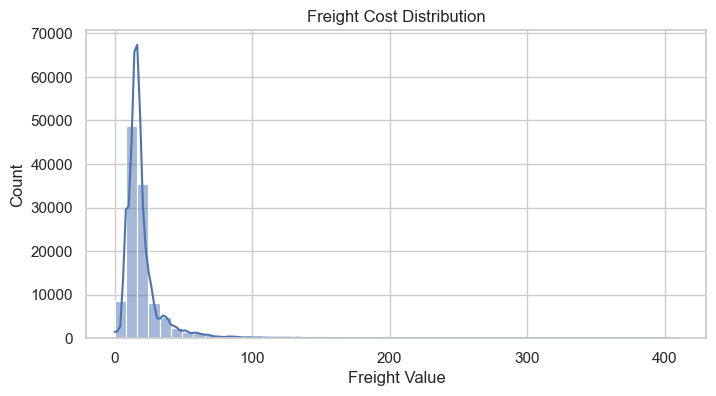

In [38]:
plt.figure(figsize=(8,4))
sns.histplot(order_items['freight_value'], bins=50, kde=True)
plt.title("Freight Cost Distribution")
plt.xlabel("Freight Value")
plt.show()

## Order Revenue Calculation

In [39]:
order_items['total_item_value'] = order_items['price'] + order_items['freight_value']

## Top Orders by Revenue

In [41]:
top_orders = (
    order_items.groupby('order_id')['total_item_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_orders

order_id
03caa2c082116e1d31e67e9ae3700499    13664.08
736e1922ae60d0d6a89247b851902527     7274.88
0812eb902a67711a1cb742b3cdaa65ae     6929.31
fefacc66af859508bf1a7934eab1e97f     6922.21
f5136e38d1a14a4dbd87dff67da82701     6726.66
2cc9089445046817a7539d90805e6e5a     6081.54
a96610ab360d42a2e5335a3998b4718a     4950.34
b4c4b76c642808cbe472a32b86cddc95     4809.44
199af31afc78c699f0dbf71fb178d4d4     4764.34
8dbc85d1447242f3b127dda390d56e19     4681.78
Name: total_item_value, dtype: float64

## Prepare Aggregated Order-Level Data

In [42]:
order_value = (
    order_items.groupby('order_id')
    .agg(
        total_order_value=('total_item_value', 'sum'),
        total_items=('order_item_id', 'count'),
        avg_item_price=('price', 'mean')
    )
    .reset_index()
)

# Save Dataset Order Items

In [43]:
os.makedirs("processed", exist_ok=True)
order_value.to_csv("processed/order_items_clean.csv", index=False)